--- RUNNING IN FULL PRODUCTION MODE ---


Running Physics Engine:   2%|▏         | 1/65 [00:07<07:31,  7.05s/it]

Domain size: (1500.0, 1500.0)
Raw X range: [0.000001, 0.999946]
Raw Z range: [0.000166, 0.999851]
Number of particles: 9216


Running Physics Engine: 100%|██████████| 65/65 [02:41<00:00,  2.49s/it]



All particles X range: [0.00, 1500.00]
All particles Z range: [0.00, 1499.99]
Grid bounds should be: X[0, 1500.0], Z[0, 1500.0]
Grid values: min=0.0434552, max=27.964, mean=4.20556, std=5.04469
Grid unique count (sampled up to 10): [0.04345521 0.05161956 0.05303868 0.05888966 0.06124791 0.06150772
 0.06338455 0.06443309 0.06505828 0.06639183] (total unique 37440)
Grid percentiles: 2%=0.176225, 98%=13.4229
Using grid clim: [0.176225, 13.4229]


/tmp/ipykernel_1436925/3371556204.py:195: UserWarning: No vector-like data to use for orient. orient will be set to False.
  droplet_spheres = point_cloud.glyph(scale="Display Size", factor=1.0, geom=pv.Sphere(phi_resolution=8, theta_resolution=8))
Compiling Final Masterpiece:   0%|          | 0/65 [00:00<?, ?it/s]/tmp/ipykernel_1436925/3371556204.py:236: UserWarning: No vector-like data to use for orient. orient will be set to False.
  updated_spheres = point_cloud.glyph(scale="Display Size", factor=1.0, geom=pv.Sphere(phi_resolution=8, theta_resolution=8))
Compiling Final Masterpiece:  98%|█████████▊| 64/65 [00:08<00:00,  7.66it/s]


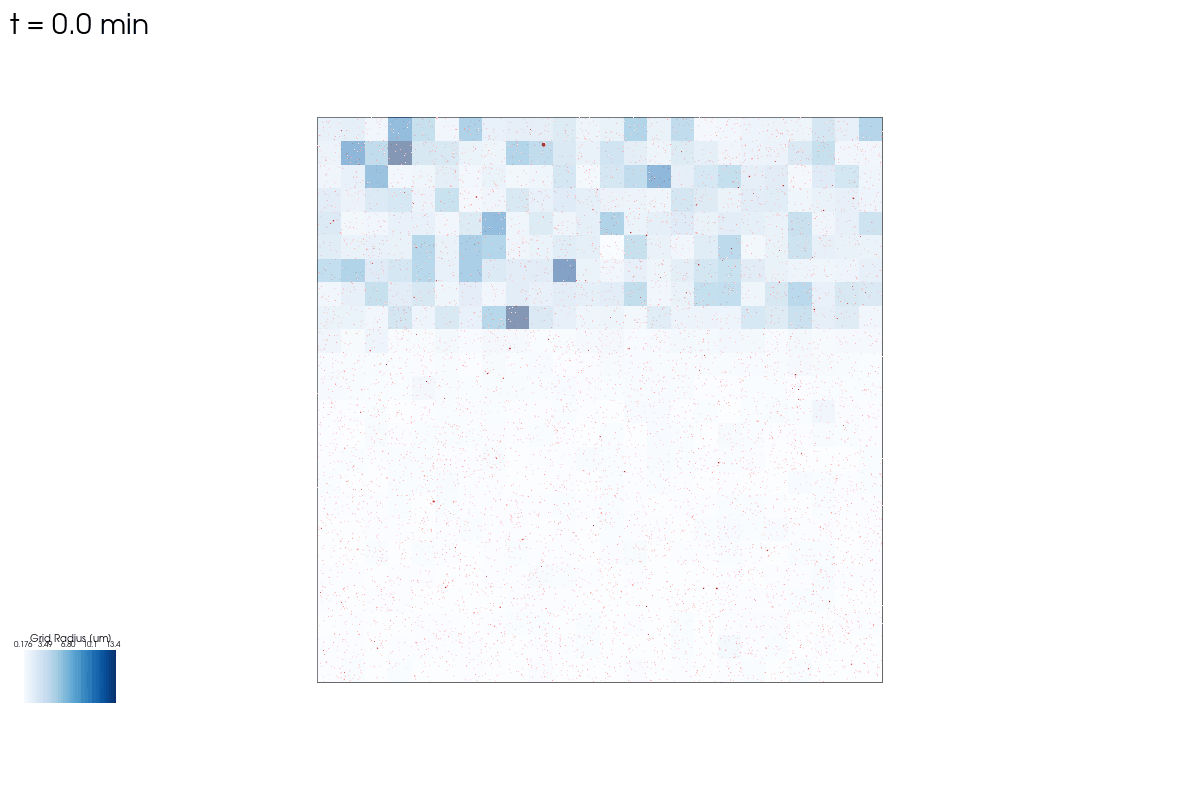

In [3]:
# %% [markdown]
# # Optimized 3D PyVista Cloud Simulation
# Fixed axis rotation, pixelated grid background, and visible particle layers.

# %%
import os
import sys
import numpy as np
from tqdm import tqdm

os.environ['NUMBA_THREADING_LAYER'] = 'workqueue'

if 'google.colab' in sys.modules:
    !apt-get install -qq xvfb
    !pip --quiet install open-atmos-jupyter-utils PySDM-examples PySDM matplotlib numpy tqdm pyvista imageio pillow
    import pyvista as pv
    pv.start_xvfb()
else:
    import pyvista as pv

from PySDM_examples.Arabas_et_al_2015 import Settings, SpinUp
from PySDM_examples.utils.kinematic_2d import Storage, Simulation
import PySDM.products as PySDM_products
from PySDM import Formulae
from PySDM.physics import si

# %% [markdown]
# ## 1. Simulation Setup

# %%
FAST_TEST_MODE = False

settings = Settings(Formulae())

if FAST_TEST_MODE:
    print("--- RUNNING IN FAST TEST MODE ---")
    settings.n_sd_per_gridbox = 8
    settings.grid = (16, 16)
    settings.simulation_time = 10 * si.minute
    settings.dt = 10 * si.second
else:
    print("--- RUNNING IN FULL PRODUCTION MODE ---")
    settings.n_sd_per_gridbox = 16
    settings.grid = (24, 24)
    settings.simulation_time = 64 * si.minute
    settings.dt = 1 * si.second

tracked_products = [PySDM_products.EffectiveRadius(unit='um')]
storage = Storage()
sim = Simulation(settings, storage, SpinUp)
sim.reinit(products=tracked_products)

product_key = list(sim.particulator.products.keys())[0]

# OPTYMALIZACJA: Szukamy kluczy atrybutów RAZ przed uruchomieniem pętli symulacji
attr_dict = sim.particulator.attributes._ParticleAttributes__attributes
keys = list(attr_dict.keys())
pos_key = [k for k in keys if 'pos' in k.lower()][0]
rad_key = [k for k in keys if 'rad' in k.lower() or 'size' in k.lower()][0]

spatial_frames = []
time_axis_min = []

# %% [markdown]
# ## 2. Fast Simulation Loop (Fixed Matrix Shapes)

# %%
spatial_frames = []
time_axis_min = []

for step in tqdm(settings.output_steps, desc="Running Physics Engine"):
    sim.particulator.run(step - sim.particulator.n_steps)
    
    # Pobieranie siatki tła
    grid_data = sim.particulator.products[product_key].get().copy()
    
    # Pobieranie obiektów cząstek
    pos_obj = attr_dict[pos_key].get() if hasattr(attr_dict[pos_key], 'get') else attr_dict[pos_key].storage
    rad_obj = attr_dict[rad_key].get() if hasattr(attr_dict[rad_key], 'get') else attr_dict[rad_key].storage
    
    raw_pos = pos_obj.ndarray.copy() if hasattr(pos_obj, 'ndarray') else np.asarray(pos_obj).copy()
    raw_r = rad_obj.ndarray.copy() if hasattr(rad_obj, 'ndarray') else np.asarray(rad_obj).copy()
    
    if np.max(raw_r) < 1e-2: 
        raw_r = raw_r * 1e6
        
    # FIX KSZTAŁTU: Sprawdzamy jak ułożona jest macierz, aby wyciągnąć współrzędne wszystkich N kropel
    if raw_pos.shape[0] == 2:
        raw_x = raw_pos[0]
        raw_z = raw_pos[1]
    else:
        raw_x = raw_pos[:, 0]
        raw_z = raw_pos[:, 1]
        
    raw_r = raw_r.flatten()
    
    # DIAGNOSTYKA: Sprawdzenie zakresu współrzędnych w pierwszej klatce
    if step == settings.output_steps[0]:
        print(f"Domain size: {settings.size}")
        print(f"Raw X range: [{raw_x.min():.6f}, {raw_x.max():.6f}]")
        print(f"Raw Z range: [{raw_z.min():.6f}, {raw_z.max():.6f}]")
        print(f"Number of particles: {len(raw_x)}")
    
    # Tworzenie właściwej macierzy 3D dla WSZYSTKICH cząstek
    # Transpose mapping: swap axes so visualization matches data orientation
    particle_coords = np.zeros((len(raw_x), 3))
    particle_coords[:, 0] = raw_z * settings.size[0]  # map raw_z -> X
    particle_coords[:, 1] = 0.1
    particle_coords[:, 2] = raw_x * settings.size[1]  # map raw_x -> Z
    
    spatial_frames.append({
        'grid': grid_data,
        'coords': particle_coords,
        'radii': raw_r
    })

# %% [markdown]
# ## 3. Render Setup: Fixed legends, uniform droplets, correct orientation

# %%
# Diagnostyka: Sprawdzenie zakresu współrzędnych przed renderowaniem
all_coords = np.vstack([f['coords'] for f in spatial_frames])
print(f"\nAll particles X range: [{all_coords[:, 0].min():.2f}, {all_coords[:, 0].max():.2f}]")
print(f"All particles Z range: [{all_coords[:, 2].min():.2f}, {all_coords[:, 2].max():.2f}]")
print(f"Grid bounds should be: X[0, {settings.size[0]}], Z[0, {settings.size[1]}]")

# compute fixed color limits for grid across whole simulation (transpose grid values)
grid_vals = np.hstack([f['grid'].T.flatten(order='C').astype(float) for f in spatial_frames])
# diagnostics
print(f"Grid values: min={np.nanmin(grid_vals):.6g}, max={np.nanmax(grid_vals):.6g}, mean={np.nanmean(grid_vals):.6g}, std={np.nanstd(grid_vals):.6g}")
print(f"Grid unique count (sampled up to 10): {np.unique(grid_vals)[:10]} (total unique {len(np.unique(grid_vals))})")

# robust percentiles to avoid single-frame domination
p2, p98 = np.nanpercentile(grid_vals, [2, 98])
print(f"Grid percentiles: 2%={p2:.6g}, 98%={p98:.6g}")

# Determine effective clim with safe fallback
if not np.isfinite(p2) or not np.isfinite(p98) or p98 <= p2:
    gmin = float(np.nanmin(grid_vals))
    gmax = float(np.nanmax(grid_vals))
    if gmax == gmin:
        # expand a bit so colormap has range
        eps = 1.0 if abs(gmin) < 1e-8 else abs(gmin) * 0.01
        grid_min, grid_max = gmin - eps, gmax + eps
    else:
        grid_min, grid_max = gmin, gmax
else:
    grid_min, grid_max = float(p2), float(p98)

print(f"Using grid clim: [{grid_min:.6g}, {grid_max:.6g}]")

global_max_radius = float(max(np.max(f['radii']) for f in spatial_frames))

plotter = pv.Plotter(notebook=True, off_screen=True, window_size=(1200, 800))
plotter.set_background('white')

# Konfiguracja ostrych komórek siatki tła (fixed clim)
# Note: transpose grid when assigning to mesh so axes match particle mapping
grid_mesh = pv.ImageData(dimensions=(settings.grid[0] + 1, 1, settings.grid[1] + 1))
grid_mesh.spacing = (settings.size[0] / settings.grid[0], 1, settings.size[1] / settings.grid[1])
# ensure float array
grid_mesh.cell_data["Grid Radius"] = np.array(spatial_frames[0]['grid'].T.flatten(order="C"), dtype=float)

# Add grid with fixed clim and a subtle scalar bar
grid_actor = plotter.add_mesh(
    grid_mesh,
    scalars="Grid Radius",
    cmap="Blues",
    clim=[grid_min, grid_max],
    opacity=0.5,
    show_scalar_bar=True,
    lighting=False,
    scalar_bar_args={
        "title": "Grid Radius [um]",
        "color": "black",
        "position_x": 0.02,
        "position_y": 0.12,
        "width": 0.08,
        "height": 0.18,
        "title_font_size": 10,
        "label_font_size": 8,
    },
)

# Konfiguracja chmury kropel - uniform red color, size encodes radius
init_coords = spatial_frames[0]['coords']
init_radii = spatial_frames[0]['radii']

point_cloud = pv.PolyData(init_coords)
point_cloud["Display Size"] = init_radii * 0.3 + 2.0
point_cloud["Real Radius"] = init_radii

# generate glyphs
# lighting=False reduces bright white highlights that make colors look different
droplet_spheres = point_cloud.glyph(scale="Display Size", factor=1.0, geom=pv.Sphere(phi_resolution=8, theta_resolution=8))

particle_actor = plotter.add_mesh(
    droplet_spheres,
    color=(1.0, 0.0, 0.0),  # uniform red
    show_scalar_bar=False,
    lighting=False,
)

# Czarne, subtelne obramowanie domeny
domain_box = pv.Box(bounds=(0, settings.size[0], 0, 0.2, 0, settings.size[1]))
plotter.add_mesh(domain_box, color="black", style="wireframe", opacity=0.2)

# Ustawienie kamery - use view_xz without extra azimuth rotation
plotter.view_xz()
plotter.camera.SetParallelProjection(True)
plotter.reset_camera()

# Aktualny czas symulacji - top-left
if spatial_frames:
    time_text = plotter.add_text("t = 0.0 min", position=(10, 760), font_size=14, color="black")
else:
    time_text = None

# %% [markdown]
# ## 4. Compile Dynamic Animation

# %%
gif_filename = 'super_droplets_cloud_perfect.gif'
plotter.open_gif(gif_filename, fps=10)

for step, frame in zip(settings.output_steps, tqdm(spatial_frames, desc="Compiling Final Masterpiece")):
    # Aktualizacja danych siatki (ostre piksele) - grid uses fixed clim
    grid_mesh.cell_data["Grid Radius"] = np.array(frame['grid'].T.flatten(order="C"), dtype=float)
    
    # Aktualizacja współrzędnych i promieni wszystkich kropel chmury
    point_cloud.points = frame['coords']
    point_cloud["Display Size"] = frame['radii'] * 0.3 + 2.0
    point_cloud["Real Radius"] = frame['radii']
    
    # Ponowne przeliczenie siatki trójwymiarowych kulek
    updated_spheres = point_cloud.glyph(scale="Display Size", factor=1.0, geom=pv.Sphere(phi_resolution=8, theta_resolution=8))
    
    # Przekazanie struktury do pamięci karty graficznej
    particle_actor.mapper.dataset = updated_spheres
    
    if time_text is not None:
        time_text.SetInput(f"t = {step / si.minute:.1f} min")
    
    plotter.render()
    plotter.write_frame()

plotter.close()

# Wyświetlenie gotowego, pięknego gifa
from IPython.display import Image, display
display(Image(filename=gif_filename))